<h1><strong>Identifying Encryption Protocol used on Ciphertext using Machine Learning</strong></h1>

<h2>Part 1: Cryptography</h2>
<hr>

Step 1: Generate random keys for AES, DES and RC5<br>
AES: 128 bits<br>
DES: 56 bits<br>
RC5: 128 bits

In [ ]:
!pip install pycryptodome

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 24.9 MB/s eta 0:00:00


In [ ]:
import os

def generate_random_keys():
    """
    Generate random keys for AES, DES, and RC5 encryption algorithms.

    Returns:
        dict: A dictionary containing keys for AES, DES, and RC5.
    """
    # AES: 128-bit key (16 bytes)
    aes_key = os.urandom(16)

    # DES: 56-bit key (7 bytes, padded to 8 bytes for DES compatibility)
    des_key = os.urandom(7) + b'\x00'

    # RC5: 128-bit key (16 bytes)
    rc5_key = os.urandom(16)

    # Return the keys in a dictionary
    return {
        "AES_key": aes_key,
        "DES_key": des_key,
        "RC5_key": rc5_key
    }

# Example usage
keys = generate_random_keys()
print("AES Key (Hex):", keys["AES_key"].hex())
print("DES Key (Hex):", keys["DES_key"].hex())
print("RC5 Key (Hex):", keys["RC5_key"].hex())

AES Key (Hex): 555dec7f843cdc4d30286e1a316f1977
DES Key (Hex): db5d74233c185900
RC5 Key (Hex): e80e5b7fb569107d131aed1c3010cd98


Step 2: RC5, AES and DES definitions<br>
RC5 - Block size: 32, Rounds: 12

In [ ]:
from Crypto.Util.Padding import pad

def rc5_key_schedule(key, w=32, r=12):
    """
    Generate the RC5 subkeys (S) based on the given key.

    Args:
        key (bytes): 128-bit key (16 bytes).
        w (int): Word size in bits (default: 32).
        r (int): Number of rounds (default: 12).

    Returns:
        list: The list of subkeys.
    """
    P = 0xB7E15163
    Q = 0x9E3779B9
    t = 2 * (r + 1)
    S = [(P + i * Q) & (2**w - 1) for i in range(t)]
    c = len(key) // (w // 8)
    L = [int.from_bytes(key[i * 4:(i + 1) * 4], byteorder="little") for i in range(c)]
    i = j = A = B = 0
    for _ in range(3 * max(t, c)):
        A = S[i] = ((S[i] + A + B) << 3 | (S[i] + A + B) >> (w - 3)) & (2**w - 1)
        B = L[j] = ((L[j] + A + B) << (A + B) % w | (L[j] + A + B) >> (w - (A + B) % w)) & (2**w - 1)
        i = (i + 1) % t
        j = (j + 1) % c
    return S

def rc5_encrypt_block(plaintext, key, w=32, r=12):
    """
    Encrypt a single block using RC5.

    Args:
        plaintext (bytes): Block to encrypt (8 bytes).
        key (bytes): 128-bit key (16 bytes).
        w (int): Word size in bits (default: 32).
        r (int): Number of rounds (default: 12).

    Returns:
        bytes: Ciphertext block (8 bytes).
    """
    A = int.from_bytes(plaintext[:4], byteorder="little")
    B = int.from_bytes(plaintext[4:], byteorder="little")
    S = rc5_key_schedule(key, w, r)
    A = (A + S[0]) & (2**w - 1)
    B = (B + S[1]) & (2**w - 1)
    for i in range(1, r + 1):
        A = ((A ^ B) << (B & (w - 1)) | (A ^ B) >> (w - (B & (w - 1)))) & (2**w - 1)
        A = (A + S[2 * i]) & (2**w - 1)
        B = ((B ^ A) << (A & (w - 1)) | (B ^ A) >> (w - (A & (w - 1)))) & (2**w - 1)
        B = (B + S[2 * i + 1]) & (2**w - 1)
    return A.to_bytes(4, byteorder="little") + B.to_bytes(4, byteorder="little")

def rc5_encrypt_full(plaintext, key, w=32, r=12):
    """
    Encrypt plaintext of any size using RC5.

    Args:
        plaintext (bytes): Plaintext to encrypt (any size).
        key (bytes): 128-bit key (16 bytes).
        w (int): Word size in bits (default: 32).
        r (int): Number of rounds (default: 12).

    Returns:
        bytes: Ciphertext.
    """
    block_size = 8  # Block size in bytes (64 bits for RC5)

    # Pad plaintext to ensure it's a multiple of the block size
    padded_plaintext = pad(plaintext, block_size)

    # Encrypt each block
    ciphertext = b"".join(rc5_encrypt_block(padded_plaintext[i:i + block_size], key, w, r)
                          for i in range(0, len(padded_plaintext), block_size))
    return ciphertext

Example Use of RC5

In [ ]:
import os

# Generate a 128-bit RC5 key
key = os.urandom(16)

# Example plaintext
plaintext = b"This is a longer plaintext example to demonstrate RC5 encryption."

# Encrypt the plaintext
ciphertext = rc5_encrypt_full(plaintext, key)

print("Plaintext:", plaintext)
print("Ciphertext (Hex):", ciphertext.hex())


Plaintext: b'This is a longer plaintext example to demonstrate RC5 encryption.'
Ciphertext (Hex): c941e1f17b8d83e26075057b2cc39ea1562a8702ed8dc7c4bdad798dee58d79c7c72a7c5bdac0e1579b8527d6f54bdae8b7cd9e65d4abe2b8e127fbfb26a0a3b053233b83c9f9090


AES Definition

In [ ]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad
import os

def aes_encrypt(plaintext, key):
    """
    Encrypt plaintext using AES encryption (CBC mode).

    Args:
        plaintext (bytes): The plaintext to encrypt (any size).
        key (bytes): The AES key (16, 24, or 32 bytes for AES-128, AES-192, or AES-256).

    Returns:
        bytes: The IV concatenated with the ciphertext.
    """
    # Ensure the key length is valid
    if len(key) not in [16, 24, 32]:
        raise ValueError("Invalid AES key size. Must be 16, 24, or 32 bytes.")

    # Initialize AES cipher in CBC mode
    cipher = AES.new(key, AES.MODE_CBC)
    iv = cipher.iv  # Initialization vector

    # Pad the plaintext to match the block size
    padded_plaintext = pad(plaintext, AES.block_size)

    # Encrypt the plaintext
    ciphertext = cipher.encrypt(padded_plaintext)
    return iv + ciphertext  # Prepend IV for use during decryption

DES Definition

In [ ]:
from Crypto.Cipher import DES
from Crypto.Util.Padding import pad
import os

def des_encrypt(plaintext, key):
    """
    Encrypt plaintext using DES encryption (CBC mode).

    Args:
        plaintext (bytes): The plaintext to encrypt (any size).
        key (bytes): The DES key (8 bytes).

    Returns:
        bytes: The IV concatenated with the ciphertext.
    """
    # Ensure the key length is valid
    if len(key) != 8:
        raise ValueError("Invalid DES key size. Must be 8 bytes.")

    # Initialize DES cipher in CBC mode
    cipher = DES.new(key, DES.MODE_CBC)
    iv = cipher.iv  # Initialization vector

    # Pad the plaintext to match the block size
    padded_plaintext = pad(plaintext, DES.block_size)

    # Encrypt the plaintext
    ciphertext = cipher.encrypt(padded_plaintext)
    return iv + ciphertext  # Prepend IV for use during decryption

Example Use of AES and DES

In [ ]:
import os

# AES Example
aes_key = os.urandom(16)  # AES-128 key
plaintext = b"This is a sample plaintext for AES encryption."
aes_ciphertext = aes_encrypt(plaintext, aes_key)
print("AES Ciphertext (Hex):", aes_ciphertext.hex())

# DES Example
des_key = os.urandom(8)  # DES key
des_ciphertext = des_encrypt(plaintext, des_key)
print("DES Ciphertext (Hex):", des_ciphertext.hex())

AES Ciphertext (Hex): 86d98fdbaf7d6bd9af803e129cef8e0f06fd0ab123bf510b36e01bf4a79eb38eae53bac0bf92442e1dc334ea70e47102193710c6465bc3edca93f05dfa08abbc
DES Ciphertext (Hex): ee84a6d8836193b5c61ce236317f58e3dcb667667c025fa22fc3b938e22719264e0a44f1eb7c8c5bea8329c7d309bea425e828a6ec8cff0c


<hr>
<hr>
<h2>Part 2: Generating Ciphertext Dataset</h2>
<hr>

In [ ]:
import pandas as pd
import json

def process_csv_and_encrypt(input_jsonl, output_csv):
    """
    Reads a JSONL file (instead of CSV), encrypts each sentence using AES, DES, and RC5,
    and saves the ciphertexts and algorithms to a new CSV file.

    Args:
        input_jsonl (str): Path to the input JSONL file (replaces CSV).
        output_csv (str): Path to save the output CSV file.
    """
    # Load the plaintext sentences from the JSONL file
    plaintext_data = []
    with open(input_jsonl, "r", encoding="utf-8") as infile:
        for line in infile:
            data = json.loads(line)
            plaintext_data.append(data["text"])  # Extract text field

    # Create a list to hold the results
    results = []

    # Create random keys
    keys = generate_random_keys()

    # Process each plaintext sentence
    for plaintext in plaintext_data:
        plaintext = plaintext.encode()  # Convert text to bytes

        # Encrypt using AES
        aes_ciphertext = aes_encrypt(plaintext, keys["AES_key"])
        results.append({"Ciphertext": aes_ciphertext.hex(), "Algorithm": "AES"})

        # Encrypt using DES
        des_ciphertext = des_encrypt(plaintext, keys["DES_key"])
        results.append({"Ciphertext": des_ciphertext.hex(), "Algorithm": "DES"})

        # Encrypt using RC5
        rc5_ciphertext = rc5_encrypt_full(plaintext, keys["RC5_key"])
        results.append({"Ciphertext": rc5_ciphertext.hex(), "Algorithm": "RC5"})

    # Convert the results to a DataFrame
    cipher_df = pd.DataFrame(results)

    # Save the DataFrame to a new CSV file
    cipher_df.to_csv(output_csv, index=False)
    print(f"Encrypted data saved to {output_csv}")


# Example Usage
input_jsonl = "data.jsonl"  # Your updated dataset (JSONL)
output_csv = "final_encrypted_data.csv"  # Output file for encrypted data

# Call the function to process and encrypt the data
process_csv_and_encrypt(input_jsonl, output_csv)


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import json

def convert_csv_to_jsonl(input_csv, output_jsonl):
    """
    Converts a CSV file with (Ciphertext, Algorithm) into a JSONL format.

    Args:
        input_csv (str): Path to the input CSV file.
        output_jsonl (str): Path to save the output JSONL file.
    """
    # Load the CSV file (assumes two columns: Ciphertext, Algorithm)
    df = pd.read_csv(input_csv, header=None, names=["text", "label"])

    # Write to JSONL format
    with open(output_jsonl, "w", encoding="utf-8") as jsonl_file:
        for _, row in df.iterrows():
            json.dump({"text": row["text"], "label": row["label"]}, jsonl_file)
            jsonl_file.write("\n")  # Newline after each JSON object

    print(f"Converted CSV to JSONL: {output_jsonl}")

# Example usage
input_csv = "final_encrypted_data.csv"  # Replace with your encrypted CSV
output_jsonl = "data.jsonl"  # Output JSONL file

convert_csv_to_jsonl(input_csv, output_jsonl)


Converted CSV to JSONL: data.jsonl


In [ ]:
import json
import pandas as pd
import random

# Define file paths
input_file = "data.jsonl"
output_file = "sampled_data.csv"

# Define the number of samples per class
num_samples_per_class = 100000  # Increased to 100,000 per class

# Read the JSONL file and organize data by algorithm
data = {"AES": [], "DES": [], "RC5": []}

with open(input_file, "r", encoding="utf-8") as f:
    for line in f:
        try:
            record = json.loads(line.strip())  # Strip any leading/trailing spaces
            label = record.get("label", "").strip()
            text = record.get("text", "").strip()

            if label in data and text:  # Ensure valid label and non-empty text
                data[label].append(text)
        except json.JSONDecodeError as e:
            print(f"Skipping malformed line: {line.strip()} - Error: {e}")

# Sample data
sampled_data = []
for label in ["AES", "DES", "RC5"]:
    sampled_texts = random.sample(data[label], min(num_samples_per_class, len(data[label])))
    sampled_data.extend([(text, label) for text in sampled_texts])

# Convert to DataFrame
df = pd.DataFrame(sampled_data, columns=["Ciphertext", "Algorithm"])

# Save to CSV
df.to_csv(output_file, index=False)

print(f"Sampled data saved to {output_file}")


Sampled data saved to sampled_data.csv


<h2>Part 3: Model Training and Testing</h2>
Linear SVC with k fold Cross Validation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Load the dataset
input_csv = "encrypted_d4.csv"  # Path to your encrypted dataset
data = pd.read_csv(input_csv)

# Step 1: Preprocess the Data
# Convert ciphertext (hex) to numerical features and pad
def hex_to_numeric_features(ciphertext_hex, max_length):
    # Convert each pair of hex characters to an integer (e.g., '4a' -> 74)
    numeric_features = [int(ciphertext_hex[i:i+2], 16) for i in range(0, len(ciphertext_hex), 2)]
    # Pad with zeros to ensure uniform length
    padded_features = numeric_features + [0] * (max_length - len(numeric_features))
    return padded_features

# Determine the maximum length of ciphertext in the dataset
max_ciphertext_length = data['Ciphertext'].apply(lambda x: len(x) // 2).max()

# Apply the conversion to all rows
data['Features'] = data['Ciphertext'].apply(lambda x: hex_to_numeric_features(x, max_ciphertext_length))

# Label encode the Algorithm column
label_encoder = LabelEncoder()
data['Label'] = label_encoder.fit_transform(data['Algorithm'])

# Extract features and labels
X = np.array(data['Features'].tolist())  # Convert list of lists to a NumPy array
y = data['Label'].values

# Step 2: k-Fold Cross-Validation
k = 2  # Number of folds
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Initialize the model
linear_svc_model = LinearSVC(max_iter=1000, random_state=42)

# Perform k-fold cross-validation
cv_scores = cross_val_score(linear_svc_model, X, y, cv=skf, scoring='accuracy')

# Print cross-validation results
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.2f}")
print(f"Standard Deviation: {cv_scores.std():.2f}")

# Step 3: Train and Evaluate on a Train-Test Split (Optional)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
linear_svc_model.fit(X_train, y_train)
y_pred = linear_svc_model.predict(X_test)

# Evaluate the model on the test set
print("\nTest Set Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Cross-Validation Accuracy Scores: [0.56523333 0.56509333]
Mean Accuracy: 0.57
Standard Deviation: 0.00

Test Set Evaluation:
Accuracy: 0.57
Classification Report:
              precision    recall  f1-score   support

         AES       0.61      0.82      0.70     20162
         DES       0.50      0.30      0.37     19857
         RC5       0.55      0.58      0.56     19981

    accuracy                           0.57     60000
   macro avg       0.55      0.57      0.55     60000
weighted avg       0.55      0.57      0.55     60000



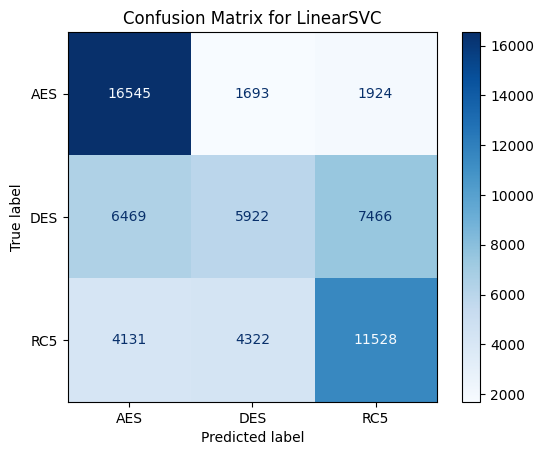

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict the labels for the test set
y_pred = linear_svc_model.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for LinearSVC")
plt.show()

XGBoost Classifier

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Load the dataset
input_csv = "sampled_data.csv"  # Path to your encrypted dataset
data = pd.read_csv(input_csv)

# Step 1: Preprocess the Data
# Convert ciphertext (hex) to numerical features and pad
def hex_to_numeric_features(ciphertext_hex, max_length):
    # Convert each pair of hex characters to an integer (e.g., '4a' -> 74)
    numeric_features = [int(ciphertext_hex[i:i+2], 16) for i in range(0, len(ciphertext_hex), 2)]
    # Pad with zeros to ensure uniform length
    padded_features = numeric_features + [0] * (max_length - len(numeric_features))
    return padded_features

# Determine the maximum length of ciphertext in the dataset
max_ciphertext_length = data['Ciphertext'].apply(lambda x: len(x) // 2).max()

# Apply the conversion to all rows
data['Features'] = data['Ciphertext'].apply(lambda x: hex_to_numeric_features(x, max_ciphertext_length))

# Label encode the Algorithm column
label_encoder = LabelEncoder()
data['Label'] = label_encoder.fit_transform(data['Algorithm'])  # Keep as integer labels

# Extract features and labels
X = np.array(data['Features'].tolist())  # Convert list of lists to a NumPy array
y = data['Label'].values  # Integer labels

# Step 2: Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train the XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=100,       # Number of trees
    learning_rate=0.1,      # Step size shrinkage
    max_depth=6,            # Maximum depth of trees
    random_state=42,
    eval_metric='mlogloss'  # Multi-class log loss
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)

# Step 4: Evaluate the Model
y_pred = xgb_model.predict(X_test)

# Calculate and print metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


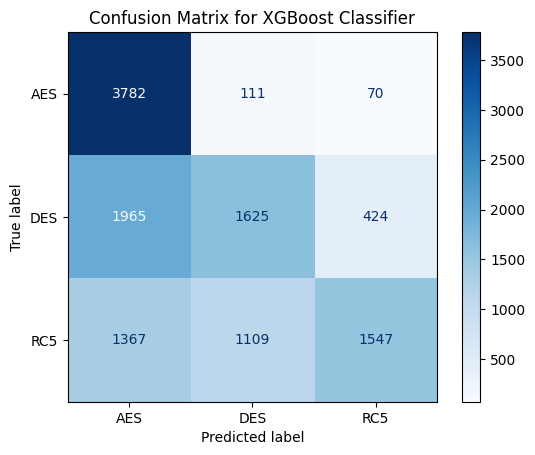

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
y_pred = xgb_model.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Classifier")
plt.show()

Random Forest Classifier

Accuracy: 0.61

Classification Report:
              precision    recall  f1-score   support

         AES       0.60      0.99      0.75     20162
         DES       0.56      0.42      0.48     19857
         RC5       0.72      0.42      0.53     19981

    accuracy                           0.61     60000
   macro avg       0.63      0.61      0.59     60000
weighted avg       0.63      0.61      0.59     60000



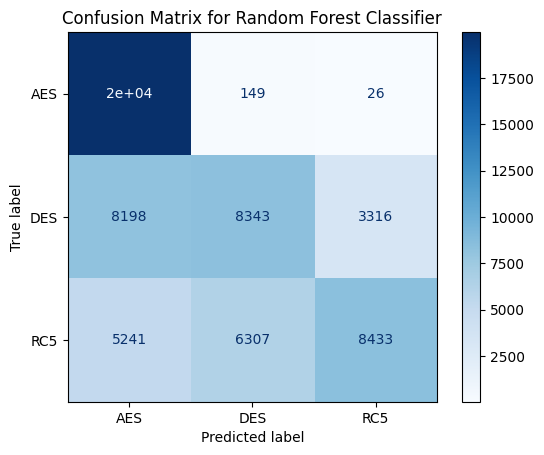

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load the dataset
input_csv = "encrypted_d4.csv"  # Path to your encrypted dataset
data = pd.read_csv(input_csv)

# Step 1: Preprocess the Data
# Convert ciphertext (hex) to numerical features and pad
def hex_to_numeric_features(ciphertext_hex, max_length):
    # Convert each pair of hex characters to an integer (e.g., '4a' -> 74)
    numeric_features = [int(ciphertext_hex[i:i+2], 16) for i in range(0, len(ciphertext_hex), 2)]
    # Pad with zeros to ensure uniform length
    padded_features = numeric_features + [0] * (max_length - len(numeric_features))
    return padded_features

# Determine the maximum length of ciphertext in the dataset
max_ciphertext_length = data['Ciphertext'].apply(lambda x: len(x) // 2).max()

# Apply the conversion to all rows
data['Features'] = data['Ciphertext'].apply(lambda x: hex_to_numeric_features(x, max_ciphertext_length))

# Label encode the Algorithm column
label_encoder = LabelEncoder()
data['Label'] = label_encoder.fit_transform(data['Algorithm'])

# Extract features and labels
X = np.array(data['Features'].tolist())  # Convert list of lists to a NumPy array
y = data['Label'].values  # Integer labels

# Step 2: Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=None,        # Allow trees to grow fully
    random_state=42,       # For reproducibility
    n_jobs=-1              # Use all available CPU cores
)
rf_model.fit(X_train, y_train)

# Step 4: Evaluate the Model
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Step 5: Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test, display_labels=label_encoder.classes_, cmap=plt.cm.Blues
)
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()